In [ ]:
import pandas as pd

users = pd.read_csv("Users.csv")
print(users.head())



   UserID        UserName  Age  Gender                             Email
0  U00001    wilsonjordan   15    Male            patricia27@hotmail.com
1  U00002        angela22   29  Female             hallrandy@hotmail.com
2  U00003  morrisonamanda   33  Female               ganderson@yahoo.com
3  U00004       fthornton   23  Female  christensencatherine@outlook.com
4  U00005  fostergeoffrey   21    Male            karenfuentes@yahoo.com


In [6]:
courses = pd.read_csv("Courses.csv")
print(courses.head())


  CourseID              CourseName CourseCategory CourseType   CourseLevel  \
0  CR00001           Python Basics    Programming       Paid      Beginner   
1  CR00002        Java Programming    Programming       Free  Intermediate   
2  CR00003       C++ for Beginners    Programming       Free      Beginner   
3  CR00004         Advanced Python    Programming       Free      Beginner   
4  CR00005  Full Stack Development    Programming       Free      Beginner   

   CoursePrice  CourseDuration  CourseRating  
0       472.28           11.00          4.74  
1         0.00           37.70          2.43  
2         0.00           19.53          3.85  
3         0.00           45.13          2.88  
4         0.00           28.68          1.28  


In [7]:
transactions = pd.read_csv("Transactions.csv")
print(transactions.head())

  TransactionID  UserID CourseID TransactionDate  Amount  PaymentMethod  \
0       TT00001  U00003  CR00016      25/10/2025     0.0         PayPal   
1       TT00002  U00003  CR00037       13/1/2025     0.0         PayPal   
2       TT00003  U00003  CR00019       28/3/2025     0.0  Bank Transfer   
3       TT00004  U00004  CR00048        2/6/2025     0.0  Bank Transfer   
4       TT00005  U00004  CR00060       10/8/2025     0.0         PayPal   

  TeacherID  
0   TC00040  
1   TC00040  
2   TC00040  
3   TC00040  
4   TC00042  


In [31]:
#Merge Data
df = transactions.merge(users, on='UserID')
df = df.merge(courses, on='CourseID')


In [ ]:
#convert raw data TO learner intelligence
#Engagement Features
engagement = df.groupby('UserID').agg({ 
    'CourseID': 'count'
}).rename(columns={'CourseID': 'total_courses'})

#Preference Features
preferred_category = df.groupby('UserID')['CourseCategory'] \
                       .agg(lambda x: x.mode()[0])

#Behavioral Features
spending = df.groupby('UserID')['Amount'].mean().rename('avg_spending')

diversity = df.groupby('UserID')['CourseCategory'].nunique().rename('diversity_score')


#Learning Depth Index
level_map = {'Beginner':1, 'Intermediate':2, 'Advanced':3}
df['LevelNum'] = df['CourseLevel'].map(level_map)

depth = df.groupby('UserID')['LevelNum'].mean().rename('learning_depth')

#Combine All Features
final_df = pd.concat([engagement, spending, diversity, depth], axis=1)
final_df = final_df.fillna(0)

#Reset index (IMPORTANT)
final_df = final_df.reset_index()
final_df.to_csv("final_df.csv", index=False)



In [71]:
final_df = pd.read_csv("final_df.csv")
user_ids = final_df['UserID']
numeric_df = final_df.select_dtypes(include=['int64', 'float64'])


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


In [ ]:
from sklearn.cluster import KMeans

# Create model
kmeans = KMeans(n_clusters=3, random_state=42)
Clusters = kmeans.fit_predict(scaled_data)

In [55]:
final_df = numeric_df.copy()
final_df['UserID'] = user_ids
final_df['Cluster'] = Clusters

In [69]:
print(final_df.columns)
# SAVE FILE
final_df.to_csv("final_df.csv", index=False)

Index(['total_courses', 'avg_spending', 'diversity_score', 'learning_depth',
       'UserID', 'Cluster'],
      dtype='str')


In [73]:
final_df.columns = final_df.columns.str.strip()

if 'cluster' in final_df.columns:
    final_df.rename(columns={'cluster': 'Cluster'}, inplace=True)

In [66]:
cluster_courses = df.merge(final_df[['UserID','Cluster']], on='UserID')

In [58]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, final_df['Cluster'])
print(score)


0.43779461340226916


In [60]:
cluster_analysis = final_df.groupby('Cluster').mean(numeric_only=True)
print(cluster_analysis)




         total_courses  avg_spending  diversity_score  learning_depth
Cluster                                                              
0             1.546139    114.081656         1.488701        2.733914
1            13.405286     93.243348         8.731278        1.978512
2             1.530997     70.450026         1.473720        1.484389


In [67]:
recommendations = cluster_courses.groupby(['Cluster','CourseID']) \
                                 .size().reset_index(name='count')


In [68]:
top_courses = df.groupby('CourseID')['CourseRating'].mean().sort_values(ascending=False)

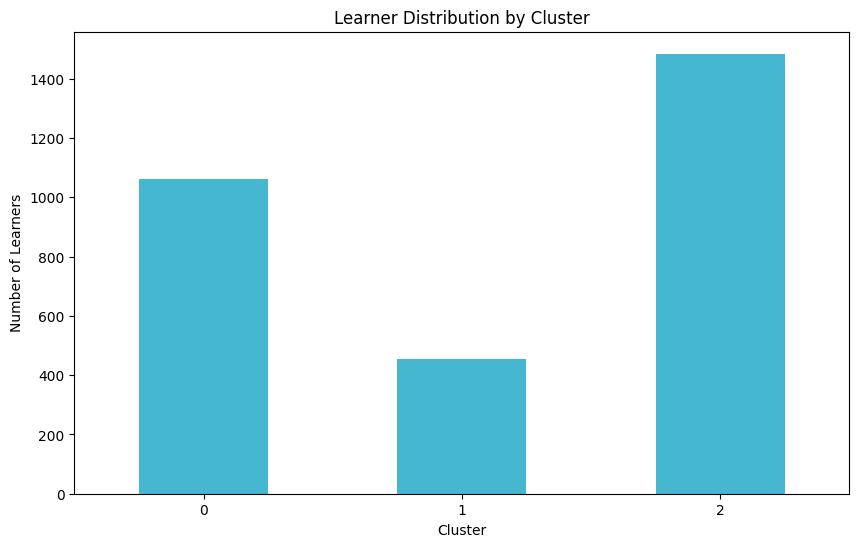

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

cluster_counts = final_df['Cluster'].value_counts().sort_index()

colors = [ '#45B7D1']
cluster_counts.plot(kind='bar', color=colors)

plt.title('Learner Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Learners')
plt.xticks(rotation=0)

plt.show()

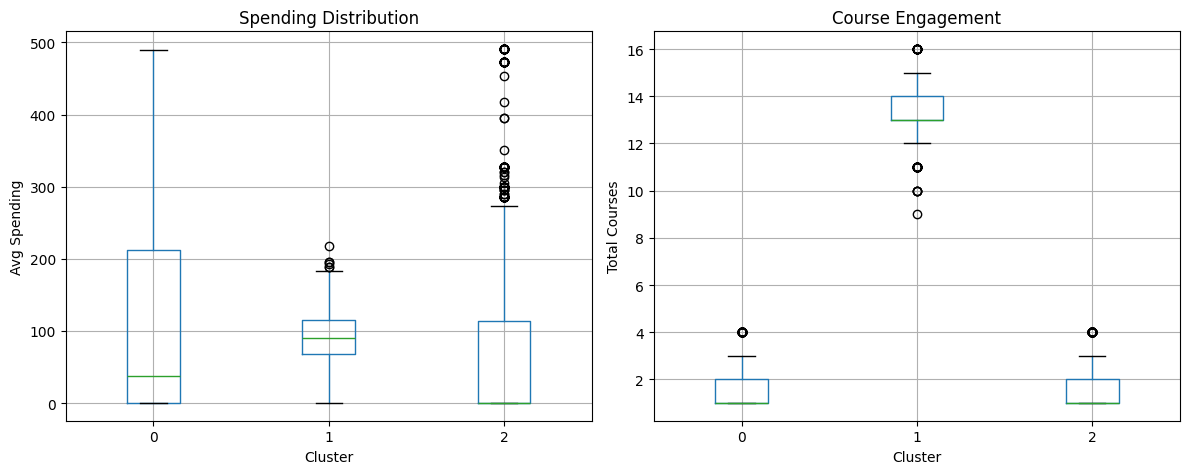

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Spending Distribution
final_df.boxplot(column='avg_spending', by='Cluster', ax=axes[0])
axes[0].set_title("Spending Distribution")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Avg Spending")

#Course Engagement
final_df.boxplot(column='total_courses', by='Cluster', ax=axes[1])
axes[1].set_title("Course Engagement")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Total Courses")
plt.suptitle("")
plt.tight_layout()
plt.show()